# analyze_all_methods - all 6 approaches, detailed style

Same look as `analyze_detailed_accuracy`: **median + IQR bands** across seeds, boxplot-per-method
distributions, the 2-panel revealed-shots view, and circuit-coverage. Reads
`all_methods_comparison/` (from `compare_all_methods.ipynb`).

**LM** appears in the final-distribution / shot-efficiency / table views (it has a final fit), but not
in the per-iteration convergence / growth panels (no iteration trace).

In [54]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import mlab
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

candidates = [
    Path.cwd(), Path.cwd() / "seed_sweep_experiments",
    Path.cwd() / "GST_POUNDERS" / "seed_sweep_experiments",
    Path("/workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments"),
]
EXPERIMENT_DIR = next((p.resolve() for p in candidates if (p / "gst_seed_experiment.py").exists()), None)
RESULTS_DIR = EXPERIMENT_DIR / "all_methods_comparison_withLM2500" #"runs_from_CHTC/run3_spam0/by_pilot/pilot_0350"
INF  = "mean_gate_entanglement_infidelity_to_truth"
SPAM = "mean_spam_vector_l2_error_to_truth"
TARGET = 1e-4
VIOLIN_CUT = 2.5   # extend violin KDE this many bandwidths past the data; 0 = matplotlib default

METHOD_ORDER = ["fixed_FPR", "no_FPR", "adaptive_D", "LM" ]
COLORS = {"fixed_FPR": "#E69F00", "no_FPR": "#009E73", "adaptive_D": "#D55E00",
          "adaptive_A": "#56B4E9", "adaptive_L": "#0072B2", "LM": "#555555"}
MARKERS = {"fixed_FPR": "s", "no_FPR": "^", "adaptive_D": "o",
           "adaptive_A": "D", "adaptive_L": "v", "LM": "*"}
FOLDER_TO_LABEL = {"fixed_fpr": "fixed_FPR", "fixed_no_fpr": "no_FPR", "adaptive_D": "adaptive_D",
                   "adaptive_A": "adaptive_A", "adaptive_L": "adaptive_L", "lm": "LM"}

# ---- load results -------------------------------------------------------------
# Read every seed directory rather than all_methods_summary.csv. That CSV only holds the
# seeds visited by the CURRENT execution of compare_all_methods cell 5 (which starts from
# `rows = []`), so earlier complete seeds are missing from it. Reading the directories also
# avoids racing the running sweep, which is still writing that file.
CORE = ["fixed_FPR", "no_FPR", "adaptive_D", "LM"]   # a seed needs all of these to count


def load_summary(results_dir, core=CORE):
    """-> (summary_df, seeds_kept, seeds_dropped). Falls back to the CSV if there are no
    seed_* directories (e.g. when RESULTS_DIR points at a runs_from_CHTC layout)."""
    rows = []
    for sd in sorted(Path(results_dir).glob("seed_*")):
        try:
            seed = int(sd.name.split("_")[1])
        except ValueError:
            continue
        for folder, label in FOLDER_TO_LABEL.items():
            f = sd / folder / "summary.json"
            if not f.exists():
                continue
            s = json.loads(f.read_text())
            row = {k: v for k, v in s.items() if not isinstance(v, (list, dict))}
            row.update(seed=seed, method=label)      # display label wins over the folder name
            rows.append(row)

    if not rows:
        csv = Path(results_dir) / "all_methods_summary.csv"
        if not csv.exists():
            raise FileNotFoundError(f"No seed_* dirs and no {csv}. Run compare_all_methods first.")
        df = pd.read_csv(csv)
        df[INF] = pd.to_numeric(df[INF], errors="coerce")
        print(f"(no seed_* dirs -- fell back to {csv.name}, {len(df)} rows)")
        return df, sorted(df["seed"].unique()), []

    df = pd.DataFrame(rows)
    df[INF] = pd.to_numeric(df[INF], errors="coerce")
    # Drop seeds missing any core method. An unbalanced panel silently biases every
    # per-method aggregate and breaks paired comparisons.
    have = df.groupby("seed")["method"].agg(set)
    keep = sorted(s for s, m in have.items() if set(core) <= m)
    dropped = sorted(set(have.index) - set(keep))
    return df[df["seed"].isin(keep)].reset_index(drop=True), keep, dropped


summary, _kept, _dropped = load_summary(RESULTS_DIR)
print(f"loaded {len(summary)} rows | seeds ({len(_kept)}): {_kept}")
if _dropped:
    print(f"dropped (incomplete): {_dropped}")
print(summary.groupby("method")["seed"].count().to_string())

# ---- failure ("second peak of the bimodal distribution") detection -------------
FAIL_COLOR   = "#B00068"   # deep magenta; validated distinct from every method hue
FAIL_MARKER  = "X"         # secondary encoding so it survives greyscale / CVD
FAIL_FACTOR   = 20        # a seed is "failed" if its metric exceeds this x the method median
FAIL_SEEDS_OVERRIDE = None # e.g. {"adaptive_D": {10002, 10006}} to pin the set by hand
FAIL_MAX_FRAC = 0.8       # the failed set must be a MINORITY to count as a second peak
FAIL_MIN_N    = 2          # need at least this many seeds before flagging anything

def failure_mask(values, factor=None, max_frac=None, min_n=None):
    """Flag the upper cluster ("second peak") of a set of per-seed values.

    A seed fails if its metric exceeds FAIL_FACTOR x the method's own median.

    A median-relative rule is used rather than a largest-gap split because the gap
    rule is unstable: as the bad tail grows, the biggest jump migrates to the most
    extreme value, so it ends up flagging only the single worst seed (or, if the
    threshold is raised to suppress that, nothing at all).

    Returns all-False when the flagged set is not a minority -- a uniformly bad
    method (e.g. no_FPR) has no second peak and would otherwise be mostly flagged.
    """
    factor = FAIL_FACTOR if factor is None else factor
    max_frac = FAIL_MAX_FRAC if max_frac is None else max_frac
    min_n = FAIL_MIN_N if min_n is None else min_n
    v = np.asarray(values, dtype=float)
    ok = np.isfinite(v) & (v > 0)
    out = np.zeros(v.shape, dtype=bool)
    n = int(ok.sum())
    if n < min_n:
        return out
    cand = ok & (v > factor * np.median(v[ok]))
    if cand.sum() == 0 or cand.sum() > max_frac * n:
        return out
    out[cand] = True
    return out


def compute_failed(frame, column=None):
    """{method: set(failed seeds)} using failure_mask on the final metric."""
    if FAIL_SEEDS_OVERRIDE is not None:
        return {m: set(FAIL_SEEDS_OVERRIDE.get(m, set())) for m in frame["method"].unique()}
    column = INF if column is None else column
    out = {}
    for m in frame["method"].unique():
        sub = frame[frame["method"] == m]
        v = pd.to_numeric(sub[column], errors="coerce").to_numpy(float)
        msk = failure_mask(v)
        out[m] = set(sub.loc[msk, "seed"].tolist()) if msk.any() else set()
    return out

def fail_legend_handle():
    return Line2D([], [], linestyle="none", marker=FAIL_MARKER, color=FAIL_COLOR,
                  markeredgecolor="black", markeredgewidth=0.5, markersize=8,
                  label="failed seed (upper cluster)")
# --------------------------------------------------------------------------------


SEPARATE_FAILED = True   # drop failed seeds from every aggregate (band/median/IQR);
                         # they are kept in FAILED_ROWS and drawn on their own.

def _refresh_failed():
    """(Re)compute FAILED from `summary`. Call again if you reload the CSV."""
    global FAILED
    FAILED = compute_failed(summary)
    return FAILED

FAILED = compute_failed(summary)
print("failure detection:",
      {m: sorted(s) for m, s in FAILED.items() if s} or
      f"NONE flagged - nothing exceeds {FAIL_FACTOR}x its method median")
FAILED_ROWS = {}          # filename -> the rows that were held back, for the comparison cell

def summary_split():
    """(non-failed rows, failed rows) of `summary`. Every aggregate uses the first."""
    keep = np.fromiter((not is_failed_row(m, s) for m, s in zip(summary["method"], summary["seed"])),
                       dtype=bool, count=len(summary))
    return summary[keep].copy(), summary[~keep].copy()          # filename -> the rows that were held back, for the comparison cell

def is_failed_row(method, seed):
    return seed in FAILED.get(method, set())

def drop_failed(frame, tag=None):
    """Split a long frame on FAILED. Returns the non-failed rows; stashes the rest
    in FAILED_ROWS[tag]. A no-op when SEPARATE_FAILED is False."""
    if frame is None or frame.empty or not SEPARATE_FAILED:
        return frame
    if not {"method", "seed"} <= set(frame.columns):
        return frame
    bad = np.fromiter((is_failed_row(m, s) for m, s in zip(frame["method"], frame["seed"])),
                      dtype=bool, count=len(frame))
    if tag is not None:
        FAILED_ROWS[tag] = frame[bad].copy()
    return frame[~bad].copy()


def _fail_label(ax):
    """'failed seed' the first time on this axis, then None (one legend entry)."""
    have = {h.get_label() for h in ax.get_lines()} | {h.get_label() for h in ax.collections}
    return None if "failed seed" in have else "failed seed"

def overlay_failed(ax, tag, xcol, ycol, method=None, xref=None, annotate=True, lw=1.5):
    """Draw the seeds that were held back at load time, on top of an aggregate plot.

    tag     : the FAILED_ROWS key (the filename passed to load_iter_table, or
              'shot_progress')
    xref    : if given, x is rescaled to [0,1] against this reference array, so the
              overlay lines up with a normalized-progress band
    method  : restrict to one method; None draws all failed seeds
    """
    rows = FAILED_ROWS.get(tag)
    if rows is None or getattr(rows, "empty", True):
        return False
    if ycol not in rows.columns or xcol not in rows.columns:
        return False
    sub = rows if method is None else rows[rows["method"] == method]
    if sub.empty:
        return False
    drawn = False
    for (mm, sd), one in sub.groupby(["method", "seed"]):
        one = one[[xcol, ycol]].apply(pd.to_numeric, errors="coerce").dropna().sort_values(xcol)
        if one.empty:
            continue
        xv = one[xcol].to_numpy(float)
        if xref is not None and len(np.asarray(xref)):
            lo, hi = float(np.min(xref)), float(np.max(xref))
            xv = (xv - lo) / max(hi - lo, 1.0)
        ax.plot(xv, one[ycol].to_numpy(float), color=FAIL_COLOR, lw=lw, alpha=0.95,
                zorder=6, label=_fail_label(ax))
        if annotate:
            ax.annotate(f"{mm} {sd}", (xv[-1], one[ycol].to_numpy(float)[-1]),
                        textcoords="offset points", xytext=(4, 0), fontsize=7.5,
                        color=FAIL_COLOR, va="center")
        drawn = True
    return drawn

def failed_frame(column=None):
    """Per-seed rows of `summary` that were classified as failures (for scatter plots)."""
    column = INF if column is None else column
    keep = [is_failed_row(m, s) for m, s in zip(summary["method"], summary["seed"])]
    return summary[np.asarray(keep, dtype=bool)]


def load_iter_table(filename):
    """Long dataframe (method=label, seed, ...) from every seed_*/<folder>/<filename>."""
    frames = []
    for path in sorted(RESULTS_DIR.glob(f"seed_*/*/{filename}")):
        folder = path.parent.name
        if folder not in FOLDER_TO_LABEL:
            continue
        try:
            frame = pd.read_csv(path)
        except Exception:
            continue
        if frame.empty:
            continue
        seed = int(path.parents[1].name.split("_")[-1])
        frame.insert(0, "method", FOLDER_TO_LABEL[folder]); frame.insert(0, "seed", seed)
        frames.append(frame)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return drop_failed(out, tag=filename)

def finite_series(frame, column):
    if column not in frame.columns:
        return pd.Series(dtype=float)
    v = pd.to_numeric(frame[column], errors="coerce")
    return v[np.isfinite(v)]

def method_boxplot(axis, frame, column, title, ylabel, log_scale=False, target=None):
    methods = [m for m in METHOD_ORDER if m in set(frame["method"])]
    vals, kept = [], []
    badvals = []
    for m in methods:
        sub = frame[frame["method"] == m]
        cur = finite_series(sub, column)
        if cur.empty:
            continue
        raw = cur.to_numpy(float)
        sd = sub.loc[cur.index, "seed"].to_numpy() if "seed" in sub.columns else np.arange(len(raw))
        bad = np.fromiter((is_failed_row(m, int(x)) for x in sd), dtype=bool, count=len(sd))
        vals.append(raw[~bad]); kept.append(m); badvals.append(raw[bad])
    if not vals:
        axis.text(0.5, 0.5, f"No {column} data", ha="center", va="center"); axis.set_axis_off(); return
    try:
        boxes = axis.boxplot(vals, tick_labels=kept, patch_artist=True, showfliers=True)
    except TypeError:
        boxes = axis.boxplot(vals, labels=kept, patch_artist=True, showfliers=True)
    for box, m in zip(boxes["boxes"], kept):
        box.set(facecolor=COLORS[m], edgecolor=COLORS[m], alpha=0.45)
    for med in boxes["medians"]:
        med.set(color="black", linewidth=1.5)
    for i, bv in enumerate(badvals):
        if len(bv):
            axis.scatter(np.full(len(bv), i + 1), bv, s=58, color=FAIL_COLOR, marker=FAIL_MARKER,
                         edgecolor="black", linewidth=0.5, zorder=6, label=_fail_label(axis))
    if log_scale:
        axis.set_yscale("log")
    if target is not None:
        axis.axhline(target, color="black", linestyle="--", linewidth=1.2, label="target")
    if axis.get_legend_handles_labels()[0]:
        axis.legend(fontsize=8.5, frameon=False)
    axis.set_title(title); axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=20); axis.grid(axis="y", alpha=0.25, which="both")

def _violin_stats(values, cut=2.0, points=256, bw_method=None):
    """KDE stats for one violin, evaluated `cut` bandwidths past the data range.

    matplotlib's violinplot hard-clips the KDE to [min, max] (see cbook.violin_stats),
    which chops the density off mid-curve and leaves a blunt flat end instead of a tail.
    Extending the evaluation grid lets the density close on its own -- the same role
    seaborn's `cut` plays. cut=0 reproduces matplotlib's default.
    """
    values = np.asarray(values, float)
    kde = mlab.GaussianKDE(values, bw_method)
    bw = float(np.sqrt(np.ravel(kde.covariance)[0]))          # kernel sd, in plot units
    coords = np.linspace(values.min() - cut * bw, values.max() + cut * bw, points)
    return {"coords": coords, "vals": kde.evaluate(coords),
            "mean": values.mean(), "median": np.median(values),
            "min": values.min(), "max": values.max(), "quantiles": []}


def method_violin(axis, frame, column, title, ylabel, log_scale=False, target=None):
    """Violin (empirical PDF) per method with the raw seed points overlaid, so tails
    are visible and honest even at small n. KDE is built in log10 space when log_scale."""
    methods = [m for m in METHOD_ORDER if m in set(frame["method"])]
    data, kept, badmasks = [], [], []
    for m in methods:
        sub = frame[frame["method"] == m]
        cur = finite_series(sub, column)
        if log_scale:
            cur = cur[cur > 0]
        if cur.empty:
            continue
        raw = cur.to_numpy(float)
        sd = sub.loc[cur.index, "seed"].to_numpy() if "seed" in sub.columns else np.arange(len(raw))
        bad = np.fromiter((is_failed_row(m, int(x)) for x in sd), dtype=bool, count=len(sd))
        data.append(raw); kept.append(m); badmasks.append(bad)
    if not data:
        axis.text(0.5, 0.5, f"No {column} data", ha="center", va="center"); axis.set_axis_off(); return
    pos = np.arange(1, len(kept) + 1)
    plot = [np.log10(d) if log_scale else d for d in data]
    # the violin body is built from the NON-FAILED seeds only, matching every other aggregate
    body = [pl[~bm] for pl, bm in zip(plot, badmasks)]
    multi = [i for i, d in enumerate(body) if len(d) >= 2 and np.ptp(d) > 0]   # KDE needs spread
    if multi:
        parts = axis.violin([_violin_stats(body[i], cut=VIOLIN_CUT) for i in multi],
                            positions=pos[multi], showextrema=False, widths=0.8)
        for body, i in zip(parts["bodies"], multi):
            body.set(facecolor=COLORS[kept[i]], edgecolor=COLORS[kept[i]], alpha=0.30)
    rng = np.random.default_rng(0)
    any_bad = False
    for i, (d, m) in enumerate(zip(plot, kept)):
        jit = (rng.random(len(d)) - 0.5) * 0.14
        bad = badmasks[i]
        axis.scatter(pos[i] + jit[~bad], d[~bad], s=24, color=COLORS[m], edgecolor="black",
                     linewidth=0.4, zorder=3, alpha=0.9)
        if bad.any():
            any_bad = True
            axis.scatter(pos[i] + jit[bad], d[bad], s=58, color=FAIL_COLOR,
                         marker=FAIL_MARKER, edgecolor="black", linewidth=0.5, zorder=5)
        good = d[~bad]
        if good.size:
            axis.plot([pos[i] - 0.28, pos[i] + 0.28], [np.median(good)] * 2,
                      color="black", lw=1.7, zorder=4)   # median bar, non-failed only
    axis.set_xticks(pos); axis.set_xticklabels(kept, rotation=20)
    if log_scale:
        lo, hi = axis.get_ylim()
        ticks = np.arange(int(np.floor(lo)), int(np.ceil(hi)) + 1)
        axis.set_yticks(ticks); axis.set_yticklabels([f"$10^{{{int(t)}}}$" for t in ticks])
        if target is not None:
            axis.axhline(np.log10(target), color="black", ls="--", lw=1.2, label="target"); axis.legend()
    elif target is not None:
        axis.axhline(target, color="black", ls="--", lw=1.2, label="target"); axis.legend()
    if any_bad:
        h, _ = axis.get_legend_handles_labels()
        axis.legend(handles=list(h) + [fail_legend_handle()], frameon=False, fontsize=8.5)
    axis.set_title(title); axis.set_ylabel(ylabel)
    axis.grid(axis="y", alpha=0.25)


def convergence_band(ax, iter_acc, metric, ylabel, title, failed=None):
    """Median + IQR per method. If `failed` ({method: set(seeds)}) is given, those
    seeds are excluded from the band and drawn individually in FAIL_COLOR."""
    failed = {} if failed is None else failed
    plotted = False
    shown_fail = False
    for m in [x for x in METHOD_ORDER if x in set(iter_acc["method"])]:
        part = iter_acc[iter_acc["method"] == m]
        bad_seeds = failed.get(m, set())
        if bad_seeds and "seed" in part.columns:
            part = part[~part["seed"].isin(bad_seeds)]   # usually already dropped at load
        if part.empty or metric not in part.columns:
            continue
        g = part.groupby("iteration")[metric]
        x = np.asarray(sorted(g.groups), dtype=int)
        med = g.median().reindex(x).to_numpy(float)
        q25 = g.quantile(0.25).reindex(x).to_numpy(float)
        q75 = g.quantile(0.75).reindex(x).to_numpy(float)
        ax.plot(x, med, color=COLORS[m], marker=MARKERS[m], markevery=max(1, len(x) // 12), label=m, lw=2.0)
        ax.fill_between(x, q25, q75, color=COLORS[m], alpha=0.18)
        plotted = True
    ax.set_yscale("log"); ax.axhline(TARGET, color="black", ls="--", lw=1.1, label=f"target {TARGET:.0e}")
    ax.set_xlabel("POUNDERS iteration"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(alpha=0.25, which="both")
    if plotted:
        ax.legend()
    return plotted

SAVE = True
seeds = sorted(summary["seed"].unique())
seeds

loaded 4 rows | seeds (1): [101]
method
LM            1
adaptive_D    1
fixed_FPR     1
no_FPR        1
failure detection: NONE flagged - nothing exceeds 20x its method median


[np.int64(101)]

## Final accuracy & cost distributions (across seeds)

Boxplot per method — median line, box = IQR. Includes **LM**.

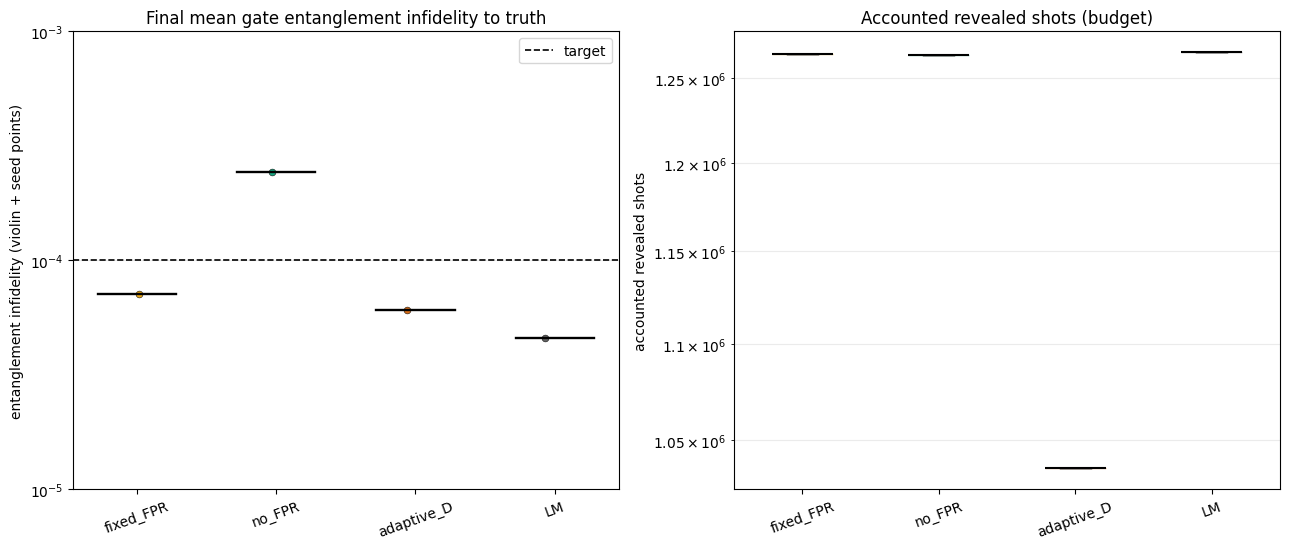

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
method_violin(axes[0], summary, INF, "Final mean gate entanglement infidelity to truth",
              "entanglement infidelity (violin + seed points)", log_scale=True, target=TARGET)
method_boxplot(axes[1], summary, "accounted_revealed_shots", "Accounted revealed shots (budget)",
               "accounted revealed shots", log_scale=True)
fig.tight_layout()
if SAVE:
    fig.savefig(RESULTS_DIR / "all_methods_final_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## Infidelity convergence (median + IQR across seeds)

LM omitted (no per-iteration trace).

LM overlay: 39 checkpoints, 1 seed(s), iterations 0-38


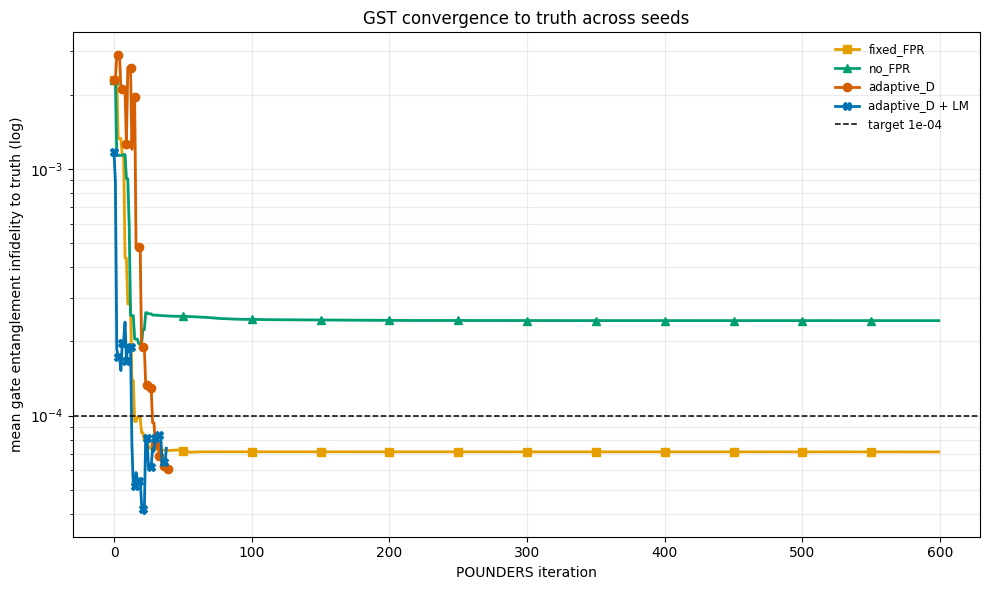

In [56]:
iter_acc = load_iter_table("iteration_accuracy.csv")

# ---- inline LM overlay --------------------------------------------------------------
# compare_all_methods writes <arm>/lm_checkpoints.csv when LM_CKPT_ENABLED is on: at each
# POUNDERS iteration it fits an LM MLE starting from POUNDERS' own iterate, on POUNDERS'
# own revealed circuits and shots (no extra data acquired). Its `iteration` column is the
# same nf as iteration_accuracy.csv, so the two share an x-axis directly.
# If the file is absent this block is a no-op and the plot is exactly as it was.
LM_CK_LABEL = "adaptive_D + LM"

def _load_lm_checkpoints():
    """Like load_iter_table, but lm_checkpoints.csv already carries its own `method`
    column (the POUNDERS method name), which would collide with the label column
    load_iter_table inserts. Drop it and label by folder, same as everything else."""
    frames = []
    for _path in sorted(RESULTS_DIR.glob("seed_*/*/lm_checkpoints.csv")):
        _folder = _path.parent.name
        if _folder not in FOLDER_TO_LABEL:
            continue
        try:
            _fr = pd.read_csv(_path)
        except Exception:
            continue
        if _fr.empty:
            continue
        _fr = _fr.drop(columns=[c for c in ("method", "arm") if c in _fr.columns])
        _fr.insert(0, "method", FOLDER_TO_LABEL[_folder])
        _fr.insert(0, "seed", int(_path.parents[1].name.split("_")[-1]))
        frames.append(_fr)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

lm_ck = _load_lm_checkpoints()
if not lm_ck.empty and ("lm_" + INF) in lm_ck.columns:
    # register the series -- convergence_band iterates METHOD_ORDER, so an unlisted label
    # is silently skipped rather than raising
    if LM_CK_LABEL not in METHOD_ORDER:
        METHOD_ORDER.append(LM_CK_LABEL)
    COLORS.setdefault(LM_CK_LABEL, "#0072B2")
    MARKERS.setdefault(LM_CK_LABEL, "X")
    lm_ck = (lm_ck.assign(method=LM_CK_LABEL)
                  .rename(columns={"lm_" + INF: INF})
                  .dropna(subset=[INF]))
else:
    lm_ck = pd.DataFrame()

if iter_acc.empty:
    print("No iteration_accuracy.csv under", RESULTS_DIR, "- run compare_all_methods first.")
else:
    combined = pd.concat([iter_acc, lm_ck], ignore_index=True) if not lm_ck.empty else iter_acc
    fig, ax = plt.subplots(figsize=(10, 6))
    convergence_band(ax, combined, INF, "mean gate entanglement infidelity to truth (log)",
                     "GST convergence to truth across seeds",
                     failed=compute_failed(summary))
    for _m in [x for x in METHOD_ORDER if x in set(iter_acc["method"])]:
        overlay_failed(ax, "iteration_accuracy.csv", "iteration", INF, method=_m)

    # mark where the shot budget ran out: past this point POUNDERS keeps optimising a
    # dataset that no longer grows, which is where the estimate can drift from truth
    if not lm_ck.empty and "at_budget_exhaustion" in lm_ck.columns:
        _exh = lm_ck.loc[lm_ck["at_budget_exhaustion"] == True, "iteration"]
        if len(_exh):
            _x = float(_exh.median())
            ax.axvline(_x, color="0.45", ls=":", lw=1.4, zorder=0)
            ax.annotate("shot budget exhausted", xy=(_x, 0.02),
                        xycoords=("data", "axes fraction"), rotation=90,
                        fontsize=7.5, color="0.35", ha="right", va="bottom")

    if not lm_ck.empty:
        print(f"LM overlay: {len(lm_ck)} checkpoints, {lm_ck['seed'].nunique()} seed(s), "
              f"iterations {int(lm_ck['iteration'].min())}-{int(lm_ck['iteration'].max())}")
    else:
        print(f"(no lm_checkpoints.csv under {RESULTS_DIR.name} - run compare_all_methods "
              f"with LM_CKPT_ENABLED = True to produce it)")

    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8.5, frameon=False)
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_convergence.png", dpi=200, bbox_inches="tight")

## Objective gradient norm (median + IQR across seeds)

The sensitivity analysis behind adaptive shot allocation assumes the estimate is near-stationary.
`ng` is the bound-projected gradient norm of the **weighted** least-squares objective on the active
(FPR-masked) residual set. Note it carries units of 1/variance, so absolute values are large;
compare methods and seeds, not the raw magnitude. LM is absent -- it is a separate pipeline with
no POUNDERS trace.


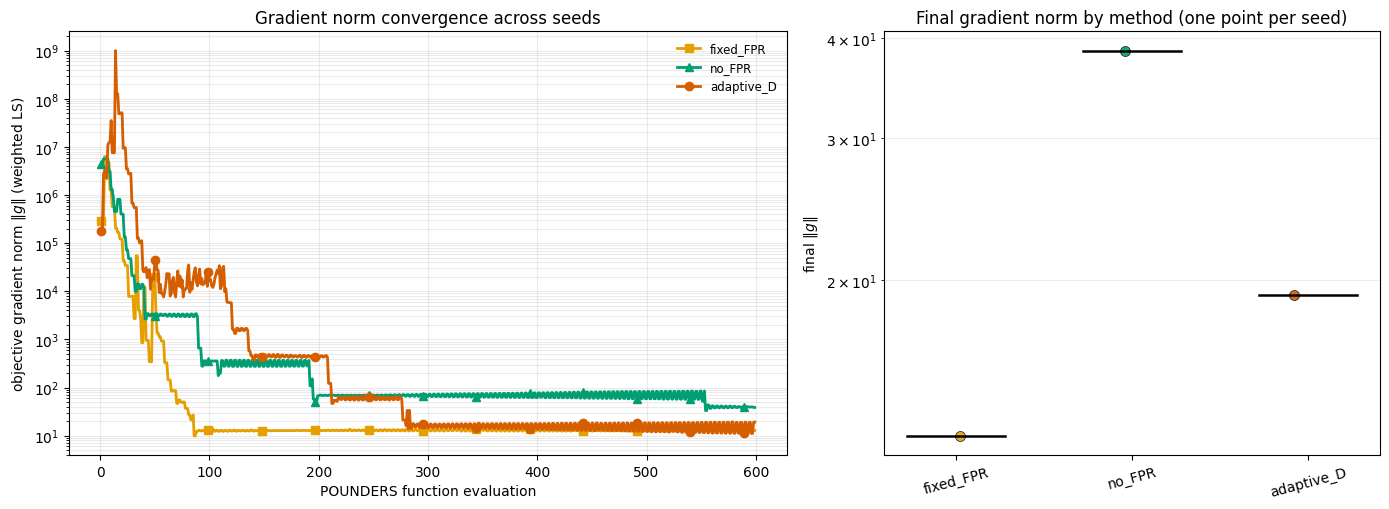

final ||g|| by method (median over seeds):
   fixed_FPR     n= 1  median=12.81  range [12.81, 12.81]
   no_FPR        n= 1  median=38.57  range [38.57, 38.57]
   adaptive_D    n= 1  median=19.17  range [19.17, 19.17]


In [50]:
# ==== Objective gradient norm: trajectories + final value by method ====
opt = load_iter_table("optimizer_progress.csv")
if opt.empty or "ng" not in opt.columns:
    print("No optimizer_progress.csv with an 'ng' column under", RESULTS_DIR)
else:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.45, 1]})

    # ---- left: median + IQR of ||g|| vs function evaluation ----
    plotted = False
    for m in [x for x in METHOD_ORDER if x in set(opt["method"])]:
        part = opt[(opt["method"] == m)][["nf", "ng"]].dropna()
        if part.empty:
            continue
        g = part.groupby("nf")["ng"]
        x = np.asarray(sorted(g.groups), dtype=float)
        med = g.median().reindex(x).to_numpy(float)
        lo = g.quantile(0.25).reindex(x).to_numpy(float)
        hi = g.quantile(0.75).reindex(x).to_numpy(float)
        ax[0].plot(x, med, color=COLORS[m], lw=2.0, label=m,
                   marker=MARKERS[m], markevery=max(1, len(x) // 12))
        ax[0].fill_between(x, lo, hi, color=COLORS[m], alpha=0.18)
        overlay_failed(ax[0], "optimizer_progress.csv", "nf", "ng", method=m)
        plotted = True
    ax[0].set_yscale("log")
    ax[0].set_xlabel("POUNDERS function evaluation")
    ax[0].set_ylabel(r"objective gradient norm $\|g\|$ (weighted LS)")
    ax[0].set_title("Gradient norm convergence across seeds")
    ax[0].grid(alpha=0.25, which="both")
    ax[0].set_axisbelow(True)
    if plotted:
        ax[0].legend(frameon=False, fontsize=8.5)

    # ---- right: final ||g|| per seed, by method ----
    finals = (opt.dropna(subset=["ng"]).sort_values("nf")
                 .groupby(["method", "seed"])["ng"].last().reset_index())
    meths = [x for x in METHOD_ORDER if x in set(finals["method"])]
    rng = np.random.default_rng(0)
    failed = compute_failed(summary)
    any_bad = False
    for i, m in enumerate(meths):
        sub = finals[finals["method"] == m]
        v = sub["ng"].to_numpy(float)
        bad = sub["seed"].isin(failed.get(m, set())).to_numpy()
        jit = (rng.random(len(v)) - 0.5) * 0.18
        ax[1].scatter(np.full(len(v), i)[~bad] + jit[~bad], v[~bad], s=52, color=COLORS[m],
                      edgecolor="black", linewidth=0.5, alpha=0.9, zorder=3)
        if bad.any():
            any_bad = True
            ax[1].scatter(np.full(len(v), i)[bad] + jit[bad], v[bad], s=76, color=FAIL_COLOR,
                          marker=FAIL_MARKER, edgecolor="black", linewidth=0.5, zorder=5)
        ax[1].plot([i - 0.28, i + 0.28], [np.median(v)] * 2, color="black", lw=1.8, zorder=4)
    if any_bad:
        ax[1].legend(handles=[fail_legend_handle()], frameon=False, fontsize=8.5, loc="upper left")
    ax[1].set_yscale("log")
    ax[1].set_xticks(range(len(meths)))
    ax[1].set_xticklabels(meths, rotation=15)
    ax[1].set_ylabel(r"final $\|g\|$")
    ax[1].set_title("Final gradient norm by method (one point per seed)")
    ax[1].grid(axis="y", alpha=0.25, which="both")
    ax[1].set_axisbelow(True)

    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_gradient_norm.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("final ||g|| by method (median over seeds):")
    for m in meths:
        v = finals[finals["method"] == m]["ng"]
        print(f"   {m:13s} n={len(v):2d}  median={v.median():.4g}  range [{v.min():.4g}, {v.max():.4g}]")


## Failed seeds versus the non-failed average

Every aggregate above (median, IQR, violin, bands) now **excludes** the failed seeds -- the
detector splits the bimodal distribution at its largest multiplicative gap and holds back the
upper cluster. This cell puts them back, one magenta line per failed seed, against the
non-failed median so the divergence is visible. Set `SEPARATE_FAILED = False` in the setup cell
to turn the whole mechanism off.


In [37]:
# ==== Failed seeds vs the non-failed average ====
print("failed seeds (upper cluster of the bimodal distribution):")
for _m, _s in FAILED.items():
    if _s:
        print(f"   {_m:13s} {sorted(_s)}")
if not any(FAILED.values()):
    print("   none detected -- nothing to separate")
else:
    acc_ok = load_iter_table("iteration_accuracy.csv")          # failures already removed
    acc_bad = FAILED_ROWS.get("iteration_accuracy.csv", pd.DataFrame())
    opt_ok = load_iter_table("optimizer_progress.csv")
    opt_bad = FAILED_ROWS.get("optimizer_progress.csv", pd.DataFrame())

    panels = [(acc_ok, acc_bad, "iteration", INF,
               "mean gate entanglement infidelity to truth", True),
              (opt_ok, opt_bad, "nf", "ng",
               r"objective gradient norm $\|g\|$", True),
              (opt_ok, opt_bad, "nf", "incumbent_active_objective",
               "incumbent active objective", True)]
    panels = [q for q in panels if not q[0].empty and q[3] in q[0].columns]

    fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 5.0), squeeze=False)
    for ax, (ok, bad, xcol, ycol, ylab, logy) in zip(axes[0], panels):
        for m in [x for x in METHOD_ORDER if x in set(ok.get("method", []))]:
            part = ok[ok["method"] == m][[xcol, ycol]].dropna()
            if part.empty:
                continue
            g = part.groupby(xcol)[ycol]
            x = np.asarray(sorted(g.groups), dtype=float)
            ax.plot(x, g.median().reindex(x).to_numpy(float), color=COLORS[m], lw=2.0,
                    label=f"{m} (non-failed median)", zorder=3)
            ax.fill_between(x, g.quantile(0.25).reindex(x).to_numpy(float),
                            g.quantile(0.75).reindex(x).to_numpy(float),
                            color=COLORS[m], alpha=0.15, zorder=2)
        shown = False
        if not bad.empty and ycol in bad.columns:
            for (m, sd), one in bad.groupby(["method", "seed"]):
                one = one[[xcol, ycol]].dropna().sort_values(xcol)
                if one.empty:
                    continue
                ax.plot(one[xcol], one[ycol], color=FAIL_COLOR, lw=1.6, alpha=0.95, zorder=5,
                        label=None if shown else "failed seeds")
                ax.annotate(f"{m} {sd}", (one[xcol].iloc[-1], one[ycol].iloc[-1]),
                            textcoords="offset points", xytext=(4, 0), fontsize=8,
                            color=FAIL_COLOR, va="center")
                shown = True
        if logy:
            ax.set_yscale("log")
        ax.set_xlabel(xcol)
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25, which="both")
        ax.set_axisbelow(True)
        ax.legend(frameon=False, fontsize=8.5)
    fig.suptitle("Failed seeds (magenta) against the non-failed median + IQR", y=1.02)
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_failed_vs_average.png", dpi=200, bbox_inches="tight")
    plt.show()


failed seeds (upper cluster of the bimodal distribution):
   none detected -- nothing to separate


## Convergence incl. LM (normalized progress)

Overlays **LM** with the POUNDERS methods. Because LM's progress is indexed by **max-length stage** (L=1..64) and POUNDERS by trust-region **iteration**, the shared x-axis is **normalized optimization progress** (0 = start → 1 = converged) — a fair shape comparison; the endpoints are the exact final infidelities. LM shown as its per-max-length-stage descent.

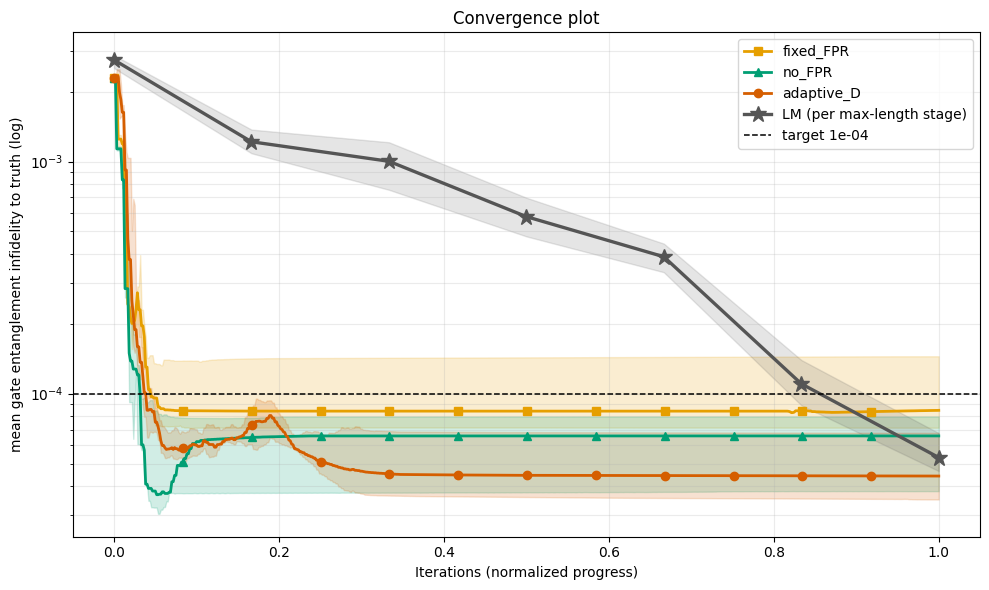

In [38]:
# ==== Convergence incl. LM, normalized progress (0=start -> 1=converged) ====
def _load_lm_traj():
    frames = []
    for path in sorted(RESULTS_DIR.glob("seed_*/lm/lm_trajectory.csv")):
        try:
            fr = pd.read_csv(path)
        except Exception:
            continue
        if fr.empty:
            continue
        fr.insert(0, "seed", int(path.parents[1].name.split("_")[-1]))
        frames.append(fr)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def _band(g):
    x = np.asarray(sorted(g.groups), dtype=float)
    return (x, g.median().reindex(x).to_numpy(float),
            g.quantile(0.25).reindex(x).to_numpy(float),
            g.quantile(0.75).reindex(x).to_numpy(float))

def _norm(x):
    span = max(x.max() - x.min(), 1.0)
    return (x - x.min()) / span

lm_traj = _load_lm_traj()
if iter_acc.empty:
    print("No POUNDERS iteration data - run compare_all_methods first.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    for m in [x for x in METHOD_ORDER if x in set(iter_acc["method"])]:
        part = iter_acc[iter_acc["method"] == m]
        if part.empty or INF not in part.columns:
            continue
        x, med, q25, q75 = _band(part.groupby("iteration")[INF]); xn = _norm(x)
        ax.plot(xn, med, color=COLORS[m], marker=MARKERS[m], markevery=max(1, len(xn) // 12), label=m, lw=2.0)
        ax.fill_between(xn, q25, q75, color=COLORS[m], alpha=0.18)
        overlay_failed(ax, "iteration_accuracy.csv", "iteration", INF, method=m, xref=x)
    if not lm_traj.empty and INF in lm_traj.columns:
        x, med, q25, q75 = _band(lm_traj.groupby("stage")[INF]); xn = _norm(x)
        ax.plot(xn, med, color=COLORS["LM"], marker=MARKERS["LM"], ms=12,
                label="LM (per max-length stage)", lw=2.4)
        ax.fill_between(xn, q25, q75, color=COLORS["LM"], alpha=0.15)
    else:
        print("No lm_trajectory.csv found - re-run LM (FORCE=True) to generate it.")
    ax.set_yscale("log"); ax.axhline(TARGET, ls="--", color="black", lw=1.1, label=f"target {TARGET:.0e}")
    ax.set_xlabel("Iterations (normalized progress)")
    ax.set_ylabel("mean gate entanglement infidelity to truth (log)")
    ax.set_title("Convergence plot")
    ax.grid(alpha=0.25, which="both"); ax.legend()
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_convergence_with_lm.png", dpi=200, bbox_inches="tight")


## SPAM convergence incl. LM (normalized progress)

Median + IQR across seeds; **LM** overlaid via its per-max-length-stage SPAM error, on the same normalized-progress axis as the infidelity version.

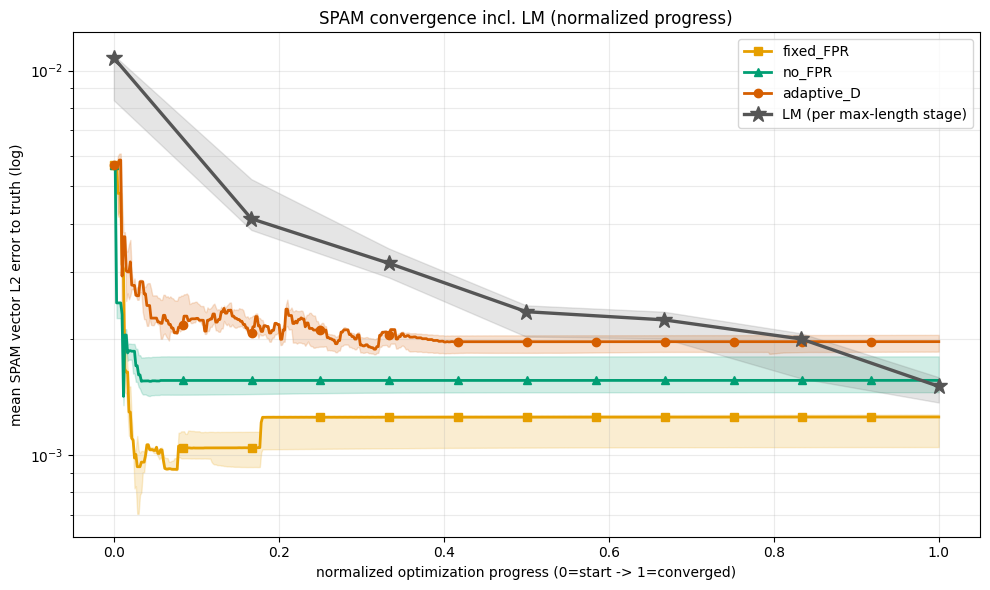

In [25]:
# ==== SPAM convergence incl. LM, normalized progress (0=start -> 1=converged) ====
def _lmtraj():
    frames = []
    for path in sorted(RESULTS_DIR.glob("seed_*/lm/lm_trajectory.csv")):
        try:
            fr = pd.read_csv(path)
        except Exception:
            continue
        if fr.empty:
            continue
        fr.insert(0, "seed", int(path.parents[1].name.split("_")[-1])); frames.append(fr)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def _nb(g):
    x = np.asarray(sorted(g.groups), dtype=float)
    return (x, g.median().reindex(x).to_numpy(float),
            g.quantile(0.25).reindex(x).to_numpy(float),
            g.quantile(0.75).reindex(x).to_numpy(float))

def _nx(x):
    return (x - x.min()) / max(x.max() - x.min(), 1.0)

_lm = _lmtraj()
if iter_acc.empty or SPAM not in iter_acc.columns:
    print("No SPAM data in iteration_accuracy.csv.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    for m in [x for x in METHOD_ORDER if x in set(iter_acc["method"])]:
        part = iter_acc[iter_acc["method"] == m]
        if part.empty or SPAM not in part.columns:
            continue
        x, med, q25, q75 = _nb(part.groupby("iteration")[SPAM]); xn = _nx(x)
        ax.plot(xn, med, color=COLORS[m], marker=MARKERS[m], markevery=max(1, len(xn) // 12), label=m, lw=2.0)
        ax.fill_between(xn, q25, q75, color=COLORS[m], alpha=0.18)
        overlay_failed(ax, "iteration_accuracy.csv", "iteration", SPAM, method=m, xref=x)
    if not _lm.empty and SPAM in _lm.columns:
        x, med, q25, q75 = _nb(_lm.groupby("stage")[SPAM]); xn = _nx(x)
        ax.plot(xn, med, color=COLORS["LM"], marker=MARKERS["LM"], ms=12, label="LM (per max-length stage)", lw=2.4)
        ax.fill_between(xn, q25, q75, color=COLORS["LM"], alpha=0.15)
    else:
        print("No lm_trajectory.csv - re-run LM to include it in SPAM convergence.")
    ax.set_yscale("log")
    ax.set_xlabel("normalized optimization progress (0=start -> 1=converged)")
    ax.set_ylabel("mean SPAM vector L2 error to truth (log)")
    ax.set_title("SPAM convergence incl. LM (normalized progress)")
    ax.grid(alpha=0.25, which="both"); ax.legend()
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_spam_convergence.png", dpi=200, bbox_inches="tight")


## Revealed-shot growth

Left: cumulative revealed shots vs iteration (median + IQR across seeds). Right: final accounted budget per method. Fixed methods reveal up front (flat); LM omitted from the trace.

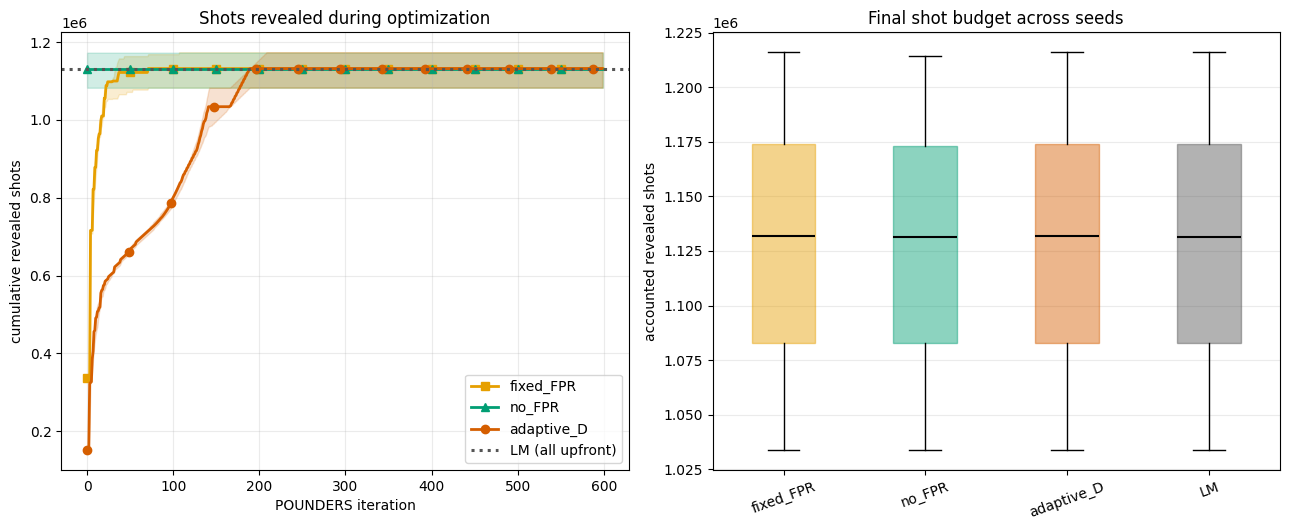

In [26]:
def load_shot_progress():
    frames = []
    for run_dir in sorted(RESULTS_DIR.glob("seed_*/*")):
        if not run_dir.is_dir():
            continue
        folder = run_dir.name
        if folder not in FOLDER_TO_LABEL:
            continue
        seed = int(run_dir.parent.name.split("_")[-1])
        if folder.startswith("adaptive_"):
            pth = run_dir / "adaptive_shot_events.csv"
            if not pth.exists() or pth.stat().st_size == 0:
                continue
            fr = pd.read_csv(pth)
            if fr.empty or "accounted_revealed_shots" not in fr:
                continue
            fr = fr[["iteration", "accounted_revealed_shots"]].rename(
                columns={"accounted_revealed_shots": "revealed_shots"})
        elif folder in ("fixed_fpr", "fixed_no_fpr"):
            pth = run_dir / "optimizer_progress.csv"
            if not pth.exists() or pth.stat().st_size == 0:
                continue
            fr = pd.read_csv(pth)
            if fr.empty or "cumulative_shots_revealed" not in fr:
                continue
            fr = fr.groupby("nf", as_index=False)["cumulative_shots_revealed"].last().rename(
                columns={"nf": "iteration", "cumulative_shots_revealed": "revealed_shots"})
        else:
            continue
        fr.insert(0, "method", FOLDER_TO_LABEL[folder]); fr.insert(0, "seed", seed)
        frames.append(fr)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return drop_failed(out, tag='shot_progress')

sp = load_shot_progress()
fig, (ax_trace, ax_final) = plt.subplots(1, 2, figsize=(13, 5.4))
if sp.empty:
    ax_trace.text(0.5, 0.5, "No shot-progress data", ha="center", va="center"); ax_trace.set_axis_off()
else:
    for m in [x for x in METHOD_ORDER if x in set(sp["method"])]:
        part = sp[sp["method"] == m]
        pivot = part.pivot_table(index="iteration", columns="seed", values="revealed_shots",
                                 aggfunc="last").sort_index()
        it = np.arange(int(pivot.index.min()), int(pivot.index.max()) + 1)
        pivot = pivot.reindex(it).ffill()
        med = pivot.median(axis=1).to_numpy(float)
        q25 = pivot.quantile(0.25, axis=1).to_numpy(float)
        q75 = pivot.quantile(0.75, axis=1).to_numpy(float)
        ax_trace.plot(it, med, color=COLORS[m], marker=MARKERS[m], markevery=max(1, len(it) // 12), label=m, lw=2.0)
        ax_trace.fill_between(it, q25, q75, color=COLORS[m], alpha=0.18)
        overlay_failed(ax_trace, "shot_progress", "iteration", "revealed_shots", method=m)
    ax_trace.set_xlabel("POUNDERS iteration"); ax_trace.set_ylabel("cumulative revealed shots")
    _lm_shots = pd.to_numeric(summary[summary["method"] == "LM"]["accounted_revealed_shots"], errors="coerce").median()
    if np.isfinite(_lm_shots):
        ax_trace.axhline(_lm_shots, ls=":", color=COLORS["LM"], lw=2.2, label="LM (all upfront)")
    ax_trace.set_title("Shots revealed during optimization"); ax_trace.grid(alpha=0.25); ax_trace.legend()

method_boxplot(ax_final, summary, "accounted_revealed_shots",
               "Final shot budget across seeds", "accounted revealed shots")
fig.tight_layout()
if SAVE:
    fig.savefig(RESULTS_DIR / "all_methods_revealed_shots.png", dpi=200, bbox_inches="tight")


## Infidelity versus revealed shots (shot efficiency)

Lower-left is best. Includes LM.

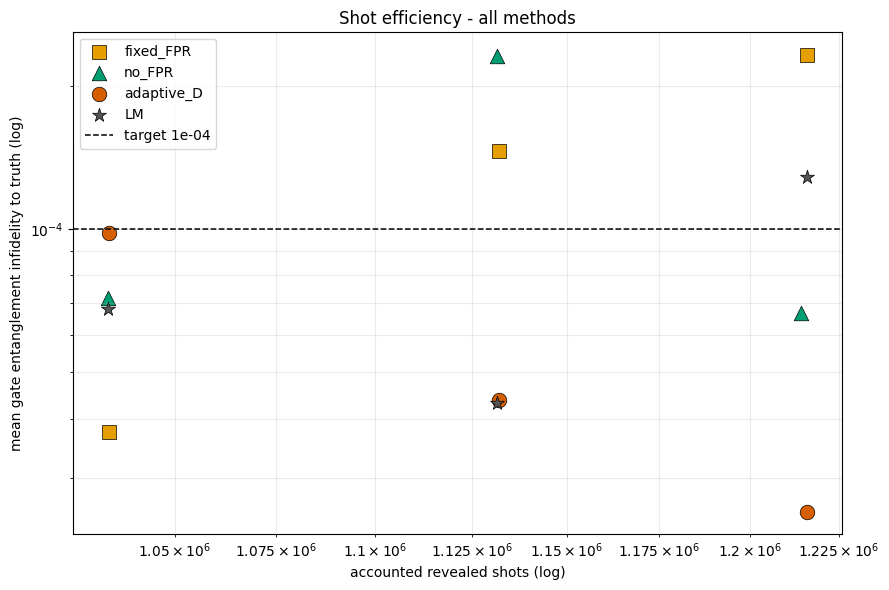

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
_bad = failed_frame()
for m in [x for x in METHOD_ORDER if x in set(summary["method"])]:
    g = summary[summary["method"] == m]
    keep = ~g["seed"].isin(_bad[_bad["method"] == m]["seed"])
    ax.scatter(pd.to_numeric(g.loc[keep, "accounted_revealed_shots"], errors="coerce"), g.loc[keep, INF],
               color=COLORS[m], marker=MARKERS[m], s=110, edgecolor="black", linewidth=0.5, label=m)
if not _bad.empty:
    ax.scatter(pd.to_numeric(_bad["accounted_revealed_shots"], errors="coerce"), _bad[INF],
               color=FAIL_COLOR, marker=FAIL_MARKER, s=150, edgecolor="black", linewidth=0.6,
               zorder=6, label="failed seed")
    for _, _r in _bad.iterrows():
        ax.annotate(f"{_r['method']} {_r['seed']}",
                    (pd.to_numeric(_r["accounted_revealed_shots"], errors="coerce"), _r[INF]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7.5, color=FAIL_COLOR)
ax.set_xscale("log"); ax.set_yscale("log")
ax.axhline(TARGET, ls="--", color="black", lw=1.1, label=f"target {TARGET:.0e}")
ax.set_xlabel("accounted revealed shots (log)"); ax.set_ylabel("mean gate entanglement infidelity to truth (log)")
ax.set_title("Shot efficiency - all methods"); ax.grid(alpha=0.25, which="both"); ax.legend()
fig.tight_layout()
if SAVE:
    fig.savefig(RESULTS_DIR / "all_methods_shot_efficiency.png", dpi=200, bbox_inches="tight")


## Infidelity vs cumulative revealed shots

The shot-efficiency *trajectory* (like `analyze_detailed_accuracy`): each incumbent accuracy measurement paired with the cumulative shots revealed by that point. Line = median across seeds, band = IQR of infidelity. Hollow marker = every iteration; filled marker = the median revealed-shot total increased there. **LM** is a batch fit (all shots up front), so it appears as a single point at its total budget. Lower-left is best.


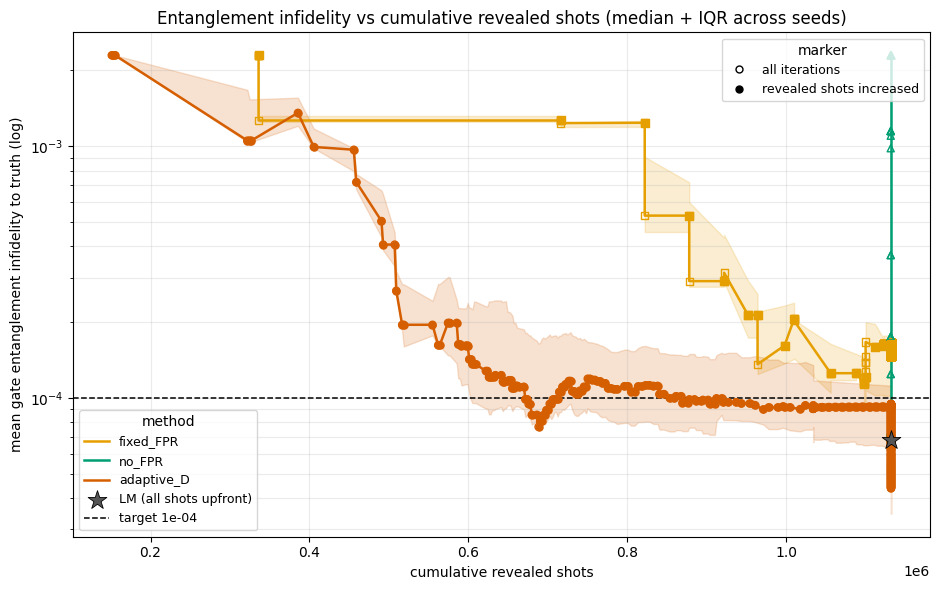

In [28]:
# ==== Infidelity vs cumulative revealed shots (median + IQR), analyze_detailed style ====
from matplotlib.lines import Line2D

sp = load_shot_progress()
acc = load_iter_table("iteration_accuracy.csv")
if sp.empty or acc.empty:
    print("Need iteration_accuracy.csv + shot-progress data - run compare_all_methods first.")
else:
    # pair each incumbent infidelity with the cumulative revealed shots at that iteration
    eff = []
    for (seed, method), a in acc.groupby(["seed", "method"]):
        s = sp[(sp["seed"] == seed) & (sp["method"] == method)]
        if s.empty or INF not in a.columns:
            continue
        a = (a[["iteration", INF]].drop_duplicates("iteration", keep="last")
             .sort_values("iteration").set_index("iteration"))
        rev = (s.groupby("iteration")["revealed_shots"].last().sort_index()
               .reindex(a.index).ffill().bfill())
        eff.append(a.assign(revealed_shots=rev, seed=seed, method=method).reset_index())
    eff = pd.concat(eff, ignore_index=True) if eff else pd.DataFrame()

    fig, ax = plt.subplots(figsize=(9.5, 6))
    _bad_rows = FAILED_ROWS.get("iteration_accuracy.csv", pd.DataFrame())
    _sp_bad = FAILED_ROWS.get("shot_progress", pd.DataFrame())
    _sp_all = sp if _sp_bad.empty else pd.concat([sp, _sp_bad], ignore_index=True)
    for m in [x for x in METHOD_ORDER if x in set(eff["method"])]:
        part = eff[eff["method"] == m].copy()
        part = part[np.isfinite(part["revealed_shots"]) & np.isfinite(part[INF])
                    & (part["revealed_shots"] > 0) & (part[INF] > 0)]
        if part.empty:
            continue
        it = np.arange(int(part["iteration"].min()), int(part["iteration"].max()) + 1)
        shots_by = part.pivot_table(index="iteration", columns="seed",
                                    values="revealed_shots", aggfunc="last").reindex(it).ffill()
        inf_by = part.pivot_table(index="iteration", columns="seed",
                                  values=INF, aggfunc="last").reindex(it).ffill()
        cs = shots_by.columns.intersection(inf_by.columns)
        shots_by, inf_by = shots_by[cs], inf_by[cs]
        if shots_by.shape[1] == 0:
            continue
        msh = shots_by.median(axis=1).to_numpy(float)
        minf = inf_by.median(axis=1).to_numpy(float)
        q25 = inf_by.quantile(0.25, axis=1).to_numpy(float)
        q75 = inf_by.quantile(0.75, axis=1).to_numpy(float)
        ax.plot(msh, minf, color=COLORS[m], lw=1.8, label=m)
        ax.scatter(msh, minf, s=26, marker=MARKERS[m], facecolors="none",
                   edgecolors=COLORS[m], linewidths=1.0, zorder=3)
        added = np.r_[True, np.diff(msh) > 0]
        ax.scatter(msh[added], minf[added], s=26, marker=MARKERS[m], color=COLORS[m],
                   edgecolors=COLORS[m], linewidths=1.0, zorder=4)
        ax.fill_between(msh, q25, q75, color=COLORS[m], alpha=0.18)

    # LM: batch fit (all shots up front) -> single reference point at its total budget
    lm = summary[summary["method"] == "LM"]
    if not lm.empty:
        lx = pd.to_numeric(lm["accounted_revealed_shots"], errors="coerce").median()
        ly = pd.to_numeric(lm[INF], errors="coerce").median()
        if np.isfinite(lx) and np.isfinite(ly):
            ax.scatter([lx], [ly], color=COLORS["LM"], marker=MARKERS["LM"], s=200,
                       edgecolor="black", linewidth=0.6, zorder=5, label="LM (all shots upfront)")

    ax.axhline(TARGET, color="black", ls="--", lw=1.1, label=f"target {TARGET:.0e}")
    # ---- the seeds held back by the failure detector, drawn individually ----
    if not _bad_rows.empty:
        for (_mm, _sd), _a in _bad_rows.groupby(["method", "seed"]):
            if INF not in _a.columns:
                continue
            _s = _sp_all[(_sp_all["seed"] == _sd) & (_sp_all["method"] == _mm)]
            if _s.empty or "revealed_shots" not in _s.columns:
                continue
            _a = (_a[["iteration", INF]].drop_duplicates("iteration", keep="last")
                  .sort_values("iteration").set_index("iteration"))
            _rev = (_s.groupby("iteration")["revealed_shots"].last().sort_index()
                    .reindex(_a.index).ffill().bfill())
            _xv = pd.to_numeric(_rev, errors="coerce").to_numpy(float)
            _yv = pd.to_numeric(_a[INF], errors="coerce").to_numpy(float)
            _ok = np.isfinite(_xv) & np.isfinite(_yv) & (_xv > 0) & (_yv > 0)
            if not _ok.any():
                continue
            ax.plot(_xv[_ok], _yv[_ok], color=FAIL_COLOR, lw=1.7, alpha=0.95, zorder=6,
                    label=_fail_label(ax))
            ax.annotate(f"{_mm} {_sd}", (_xv[_ok][-1], _yv[_ok][-1]),
                        textcoords="offset points", xytext=(5, 0), fontsize=7.5,
                        color=FAIL_COLOR, va="center")
    ax.set_yscale("log")
    ax.set_xlabel("cumulative revealed shots")
    ax.set_ylabel("mean gate entanglement infidelity to truth (log)")
    ax.set_title("Entanglement infidelity vs cumulative revealed shots (median + IQR across seeds)")
    ax.grid(alpha=0.25, which="both")
    method_legend = ax.legend(loc="lower left", fontsize=9, title="method")
    ax.add_artist(method_legend)
    marks = [Line2D([0], [0], marker="o", linestyle="none", markersize=5,
                    markerfacecolor="white", markeredgecolor="black", label="all iterations"),
             Line2D([0], [0], marker="o", linestyle="none", markersize=5,
                    markerfacecolor="black", markeredgecolor="black", label="revealed shots increased")]
    if any(h.get_label() == "failed seed" for h in ax.get_lines()):
        marks.append(Line2D([0], [0], color=FAIL_COLOR, lw=1.7, label="failed seed"))
    ax.legend(handles=marks, loc="upper right", fontsize=9, title="marker")
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_infidelity_vs_shots.png", dpi=200, bbox_inches="tight")
    plt.show()


## Circuit-sampling coverage (adaptive methods)

One seed (`COVERAGE_SEED`): sorted shots/circuit + Lorenz concentration. Fixed/LM omitted (uniform).

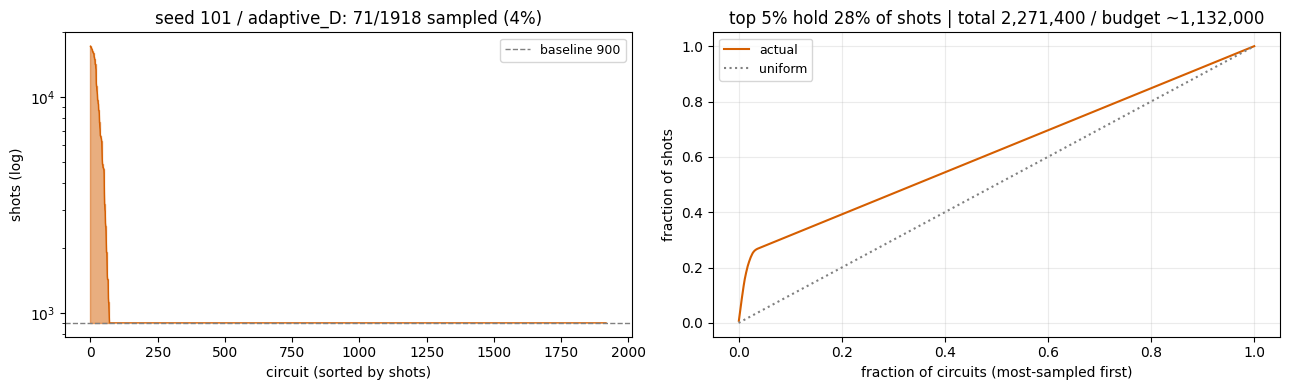

In [29]:
COVERAGE_SEED = seeds[0]
sd = RESULTS_DIR / f"seed_{COVERAGE_SEED:06d}"
cov = []
for folder in [f for f in ["adaptive_D", "adaptive_A", "adaptive_L"] if FOLDER_TO_LABEL[f] in METHOD_ORDER]:
    npy = sd / folder / "final_shots_per_circuit.npy"
    if not npy.exists():
        continue
    summ_p = sd / folder / "summary.json"
    summ = json.loads(summ_p.read_text()) if summ_p.exists() else {}
    cov.append({"label": FOLDER_TO_LABEL[folder], "shots": np.load(npy).astype(float), "summary": summ})
if not cov:
    print("No adaptive final_shots_per_circuit.npy for seed", COVERAGE_SEED)
else:
    n = len(cov)
    fig, axes = plt.subplots(n, 2, figsize=(13, 4.0 * n), squeeze=False)
    for i, r in enumerate(cov):
        s = r["shots"]; total = s.size; base = int(s.min()); samp = int((s > base).sum())
        srt = np.sort(s)[::-1]; bud = r["summary"].get("accounted_revealed_shots", int(s.sum()))
        axL = axes[i][0]
        axL.fill_between(np.arange(total), srt, base, where=srt > base, color=COLORS.get(r["label"], "#0072B2"), alpha=0.5, step="pre")
        axL.plot(np.arange(total), srt, color=COLORS.get(r["label"], "#0072B2"), lw=1)
        axL.axhline(base, ls="--", color="gray", lw=1, label=f"baseline {base}")
        axL.set_yscale("log"); axL.set_xlabel("circuit (sorted by shots)"); axL.set_ylabel("shots (log)")
        axL.set_title(f"seed {COVERAGE_SEED} / {r['label']}: {samp}/{total} sampled ({100*samp/total:.0f}%)")
        axL.legend(fontsize=9)
        axR = axes[i][1]; cum = np.cumsum(srt) / srt.sum(); fr = np.arange(1, total + 1) / total
        axR.plot(fr, cum, color="#D55E00", label="actual"); axR.plot([0, 1], [0, 1], ls=":", color="gray", label="uniform")
        top5 = cum[max(0, int(0.05 * total) - 1)]
        axR.set_xlabel("fraction of circuits (most-sampled first)"); axR.set_ylabel("fraction of shots")
        axR.set_title(f"top 5% hold {100*top5:.0f}% of shots | total {int(s.sum()):,} / budget ~{int(bud):,}")
        axR.legend(fontsize=9); axR.grid(alpha=0.25)
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_circuit_coverage.png", dpi=150)
    plt.show()

## Shot distribution across selected circuits (all methods)

How each method spreads its budget over the circuits it actually measures (its **selected/revealed** set = union of FPR-selected circuits; all circuits for no_FPR/LM). Median + IQR bands across seeds.

- **Left - allocation:** shots per circuit (log), circuits sorted most-sampled first, x normalized to *fraction of selected circuits* so methods with different circuit counts are comparable.
- **Right - concentration (Lorenz):** cumulative share of shots vs fraction of circuits; the diagonal is perfectly uniform. **Gini** in the legend (0 = uniform, higher = more concentrated).


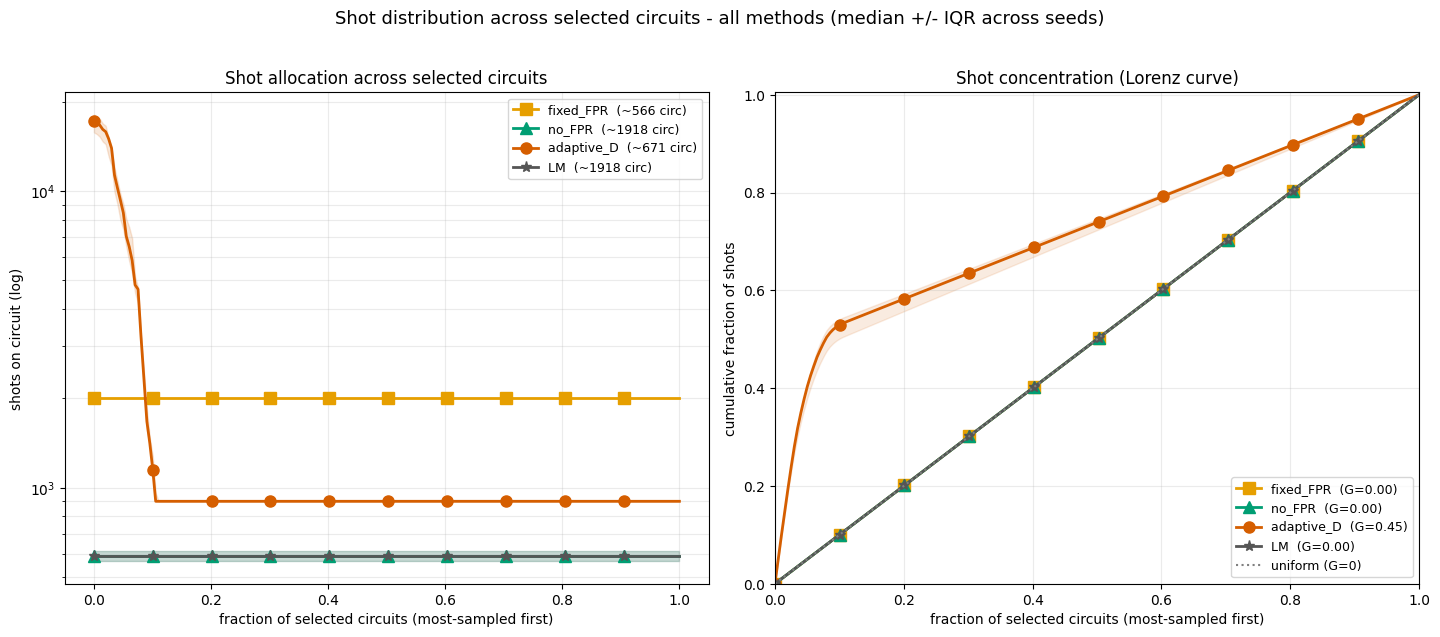

median concentration across seeds:
  method       n_sel   gini  top1%share
  fixed_FPR      566   0.00       1.0%
  no_FPR        1918   0.00       1.0%
  adaptive_D     671   0.45       9.7%
  LM            1918   0.00       1.0%


In [30]:
# ==== Shot distribution across selected circuits, all methods (median + IQR) ====
import ast
from collections import defaultdict

def _selected_shots(run_dir, folder):
    """(shots on selected circuits, accounted) for one run.
    selected = union of selected_circuit_indices across FPR calls;
    all circuits when there is no FPR history; LM reconstructed as flat mean."""
    summ_p = run_dir / "summary.json"
    if not summ_p.exists():
        return None, None
    summ = json.loads(summ_p.read_text())
    total = int(summ.get("total_circuits", 1918))
    acc = int(summ.get("accounted_revealed_shots", 0))
    if folder == "lm":
        mean = float(summ.get("mean_shots_per_circuit", acc / max(total, 1)))
        return np.full(total, mean), acc
    npy_p = run_dir / "final_shots_per_circuit.npy"
    if not npy_p.exists():
        return None, None
    shots = np.load(npy_p).astype(float)
    sel = None
    fpr = run_dir / "fpr_selection_history.csv"
    if fpr.exists() and fpr.stat().st_size > 5:
        try:
            fr = pd.read_csv(fpr, usecols=["selected_circuit_indices"])
            idx = set()
            for s in fr["selected_circuit_indices"].dropna():
                s = str(s).strip()
                if s and s != "[]":
                    idx.update(ast.literal_eval(s))
            if idx:
                sel = np.fromiter(sorted(idx), dtype=int)
        except Exception:
            sel = None
    if sel is None:
        sel = np.arange(len(shots))
    return shots[sel], acc

def _gini(x):
    x = np.sort(np.asarray(x, dtype=float)); n = x.size
    if n == 0 or x.sum() == 0:
        return 0.0
    return (2.0 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1.0) / n

GRID = np.linspace(0.0, 1.0, 200)
rank_curves = defaultdict(list)     # label -> list of shots-at-GRID-fraction arrays
lorenz_curves = defaultdict(list)   # label -> list of cumulative-share arrays
ginis = defaultdict(list)
nsel = defaultdict(list)

for seed in seeds:
    sdir = RESULTS_DIR / f"seed_{seed:06d}"
    for folder, label in FOLDER_TO_LABEL.items():
        shots, _acc = _selected_shots(sdir / folder, folder)
        if shots is None or shots.size == 0:
            continue
        srt = np.sort(shots)[::-1]                       # most-sampled first
        n = srt.size
        xf = (np.arange(1, n + 1) - 0.5) / n
        rank_curves[label].append(np.interp(GRID, xf, srt))
        xl = np.concatenate([[0.0], np.arange(1, n + 1) / n])
        yl = np.concatenate([[0.0], np.cumsum(srt) / srt.sum()])
        lorenz_curves[label].append(np.interp(GRID, xl, yl))
        ginis[label].append(_gini(shots))
        nsel[label].append(n)

def _band(curves):
    M = np.vstack(curves)
    return np.median(M, 0), np.quantile(M, 0.25, 0), np.quantile(M, 0.75, 0)

if not rank_curves:
    print("No final_shots_per_circuit data found - run compare_all_methods first.")
else:
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(14.5, 6.2))
    order = [m for m in METHOD_ORDER if m in rank_curves]

    # Panel A: allocation (shots per circuit, log-y)
    for m in order:
        med, q25, q75 = _band(rank_curves[m])
        nlab = int(np.median(nsel[m]))
        axA.plot(GRID, med, color=COLORS[m], marker=MARKERS[m], markevery=20,
                 ms=8, lw=2.0, label=f"{m}  (~{nlab} circ)")
        axA.fill_between(GRID, q25, q75, color=COLORS[m], alpha=0.15)
    axA.set_yscale("log")
    axA.set_xlabel("fraction of selected circuits (most-sampled first)")
    axA.set_ylabel("shots on circuit (log)")
    axA.set_title("Shot allocation across selected circuits")
    axA.grid(alpha=0.25, which="both"); axA.legend(fontsize=9, loc="upper right")

    # Panel B: concentration (Lorenz), Gini in legend
    for m in order:
        med, q25, q75 = _band(lorenz_curves[m])
        axB.plot(GRID, med, color=COLORS[m], marker=MARKERS[m], markevery=20,
                 ms=8, lw=2.0, label=f"{m}  (G={np.median(ginis[m]):.2f})")
        axB.fill_between(GRID, q25, q75, color=COLORS[m], alpha=0.12)
    axB.plot([0, 1], [0, 1], ls=":", color="gray", lw=1.5, label="uniform (G=0)")
    axB.set_xlim(0, 1); axB.set_ylim(0, 1.005)
    axB.set_xlabel("fraction of selected circuits (most-sampled first)")
    axB.set_ylabel("cumulative fraction of shots")
    axB.set_title("Shot concentration (Lorenz curve)")
    axB.grid(alpha=0.25); axB.legend(fontsize=9, loc="lower right")

    fig.suptitle("Shot distribution across selected circuits - all methods (median +/- IQR across seeds)",
                 y=1.02, fontsize=13)
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_shot_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("median concentration across seeds:")
    print(f"  {'method':11} {'n_sel':>6} {'gini':>6} {'top1%share':>11}")
    for m in order:
        top1 = np.median([np.sort(rc)[::-1][:max(1, rc.size // 100)].sum() / rc.sum()
                          for rc in rank_curves[m]])
        print(f"  {m:11} {int(np.median(nsel[m])):>6} {np.median(ginis[m]):>6.2f} {top1:>10.1%}")


## Shot allocation per circuit index (per seed)

The allocation vs the **actual circuit index** (design order, so low index ≈ short circuits, high index ≈ long circuits) — **one panel per seed**. Set `SEEDS_TO_SHOW` to a subset (e.g. `[101]` or `seeds[:4]`) if the grid gets too tall. Each point is one selected circuit; a method's missing indices are circuits it didn't select. adaptive_D's tall spikes reveal which circuits it pours the budget into (they cluster at the long, high-index circuits); fixed_FPR / no_FPR / LM are flat bands.


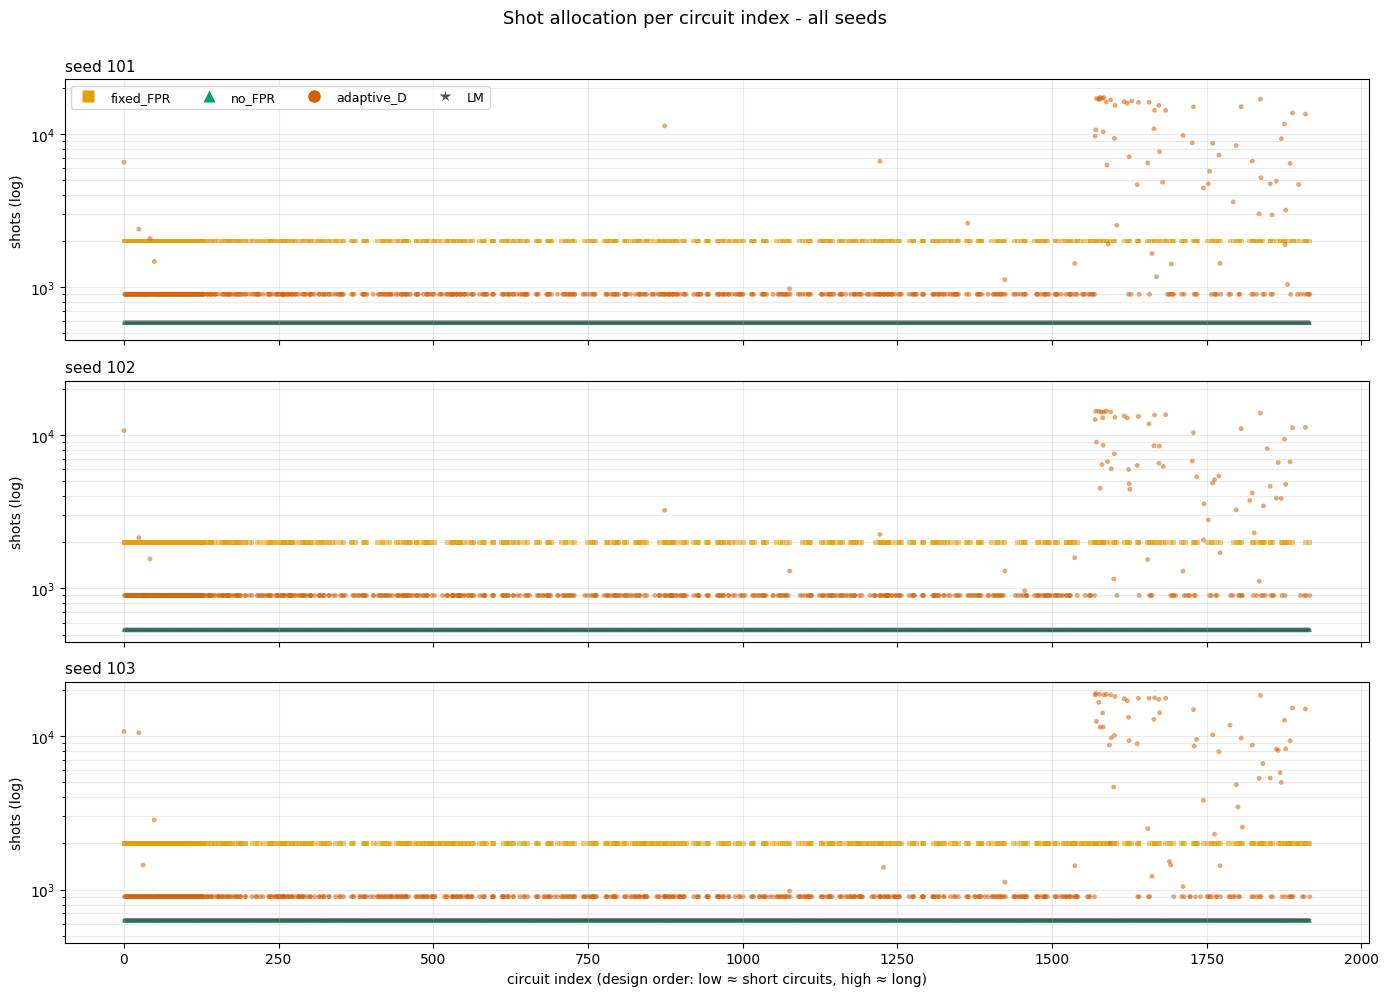

In [31]:
# ==== Shot allocation per circuit index, one panel per seed ====
import ast
from matplotlib.lines import Line2D

SEEDS_TO_SHOW = list(seeds)          # <- set to e.g. [101] or seeds[:4] to subset
_label_to_folder = {v: k for k, v in FOLDER_TO_LABEL.items()}

def _shots_by_index(run_dir, folder):
    """(indices, shots) on the method's selected circuits (union of FPR-selected
    indices; all circuits when there is no FPR history; LM reconstructed flat)."""
    summ_p = run_dir / "summary.json"
    if not summ_p.exists():
        return None, None
    summ = json.loads(summ_p.read_text())
    total = int(summ.get("total_circuits", 1918))
    if folder == "lm":
        mean = float(summ.get("mean_shots_per_circuit",
                              summ.get("accounted_revealed_shots", 0) / max(total, 1)))
        return np.arange(total), np.full(total, mean)
    npy_p = run_dir / "final_shots_per_circuit.npy"
    if not npy_p.exists():
        return None, None
    shots = np.load(npy_p).astype(float)
    sel = None
    fpr = run_dir / "fpr_selection_history.csv"
    if fpr.exists() and fpr.stat().st_size > 5:
        try:
            fr = pd.read_csv(fpr, usecols=["selected_circuit_indices"])
            idx = set()
            for s in fr["selected_circuit_indices"].dropna():
                s = str(s).strip()
                if s and s != "[]":
                    idx.update(ast.literal_eval(s))
            if idx:
                sel = np.fromiter(sorted(idx), dtype=int)
        except Exception:
            sel = None
    if sel is None:
        sel = np.arange(len(shots))
    return sel, shots[sel]

_seeds_show = list(SEEDS_TO_SHOW)
if not _seeds_show:
    print("SEEDS_TO_SHOW is empty.")
else:
    n = len(_seeds_show)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.3 * n), squeeze=False,
                             sharex=True, sharey=True)
    plotted_methods, first_ax = [], None
    for r, seed in enumerate(_seeds_show):
        ax = axes[r][0]
        sdir = RESULTS_DIR / f"seed_{int(seed):06d}"
        any_here = False
        for m in [x for x in METHOD_ORDER if x in _label_to_folder]:
            folder = _label_to_folder[m]
            idx, sh = _shots_by_index(sdir / folder, folder)
            if idx is None or idx.size == 0:
                continue
            ax.scatter(idx, sh, s=12, marker=MARKERS[m], color=COLORS[m],
                       alpha=0.55, edgecolors="none")
            any_here = True
            if m not in plotted_methods:
                plotted_methods.append(m)
        if not any_here:
            ax.text(0.5, 0.5, f"seed {int(seed)}: no data yet", ha="center", va="center",
                    transform=ax.transAxes)
            continue
        ax.set_yscale("log")
        ax.set_ylabel("shots (log)")
        _fail_here = sorted(m for m in FAILED if int(seed) in FAILED[m])
        if _fail_here:
            ax.set_title(f"seed {int(seed)}   [FAILED: {', '.join(_fail_here)}]", loc="left",
                         fontsize=11, color=FAIL_COLOR, fontweight="bold")
            for _sp in ax.spines.values():
                _sp.set_color(FAIL_COLOR); _sp.set_linewidth(1.8)
        else:
            ax.set_title(f"seed {int(seed)}", loc="left", fontsize=11)
        ax.grid(alpha=0.25, which="both")
        if first_ax is None:
            first_ax = ax
    axes[-1][0].set_xlabel("circuit index (design order: low \u2248 short circuits, high \u2248 long)")
    if first_ax is not None and plotted_methods:
        handles = [Line2D([0], [0], marker=MARKERS[m], linestyle="none",
                          markerfacecolor=COLORS[m], markeredgecolor="none", markersize=9, label=m)
                   for m in METHOD_ORDER if m in plotted_methods]
        first_ax.legend(handles=handles, fontsize=9, loc="upper left", ncol=len(handles))
    fig.suptitle("Shot allocation per circuit index - all seeds", y=1.002, fontsize=13)
    fig.tight_layout()
    if SAVE:
        fig.savefig(RESULTS_DIR / "all_methods_shot_allocation_by_index.png",
                    dpi=170, bbox_inches="tight")
    plt.show()


## Median summary table

In [32]:
_ok, _bad = summary_split()
tbl = _ok.groupby("method").agg(
    median_infidelity=(INF, "median"),
    median_accounted_shots=("accounted_revealed_shots", "median"),
    median_max_shots_per_circuit=("max_shots_per_circuit", "median"),
    n_seeds=("seed", "count"),
).reindex([m for m in METHOD_ORDER if m in set(summary["method"])])
tbl["n_failed"] = [len(FAILED.get(m, set())) for m in tbl.index]
tbl["failed_seeds"] = [", ".join(str(s) for s in sorted(FAILED.get(m, set()))) or "-" for m in tbl.index]
print(tbl.to_string())
print()
if SEPARATE_FAILED:
    print("note: the medians above EXCLUDE the failed seeds listed in failed_seeds.")
    print("      set SEPARATE_FAILED = False in the setup cell to include them.")
else:
    print("note: SEPARATE_FAILED is False - failed seeds are included in every aggregate.")


            median_infidelity  median_accounted_shots  median_max_shots_per_circuit  n_seeds  n_failed failed_seeds
method                                                                                                             
fixed_FPR            0.000146               1132000.0                        2000.0        3         0            -
no_FPR               0.000072               1131620.0                         590.0        3         0            -
adaptive_D           0.000044               1132000.0                       17256.0        3         0            -
LM                   0.000068               1131620.0                         590.0        3         0            -

note: the medians above EXCLUDE the failed seeds listed in failed_seeds.
      set SEPARATE_FAILED = False in the setup cell to include them.
